In [2]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_csv("hospital data.csv")

In [45]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,37,male,34.100,4.0,yes,southwest,40182.24600
1,18,male,34.430,0.0,no,southeast,1137.46970
2,23,female,36.670,2.0,yes,northeast,38511.62830
3,32,male,35.200,2.0,no,southwest,4670.64000
4,58,female,32.395,1.0,no,northeast,13019.16105


In [46]:
df.isnull().sum()

age          0
sex         10
bmi          5
children     4
smoker       6
region       4
charges      4
dtype: int64

# handling null values

In [47]:
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df["children"] = df["children"].fillna(df["children"].median())
df["smoker"] = df["smoker"].fillna(df["smoker"].mode()[0])
df["region"] = df["region"].fillna(df["region"].mode()[0])
df["charges"] = df["charges"].fillna(df["charges"].mean())

In [48]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# outlier detection

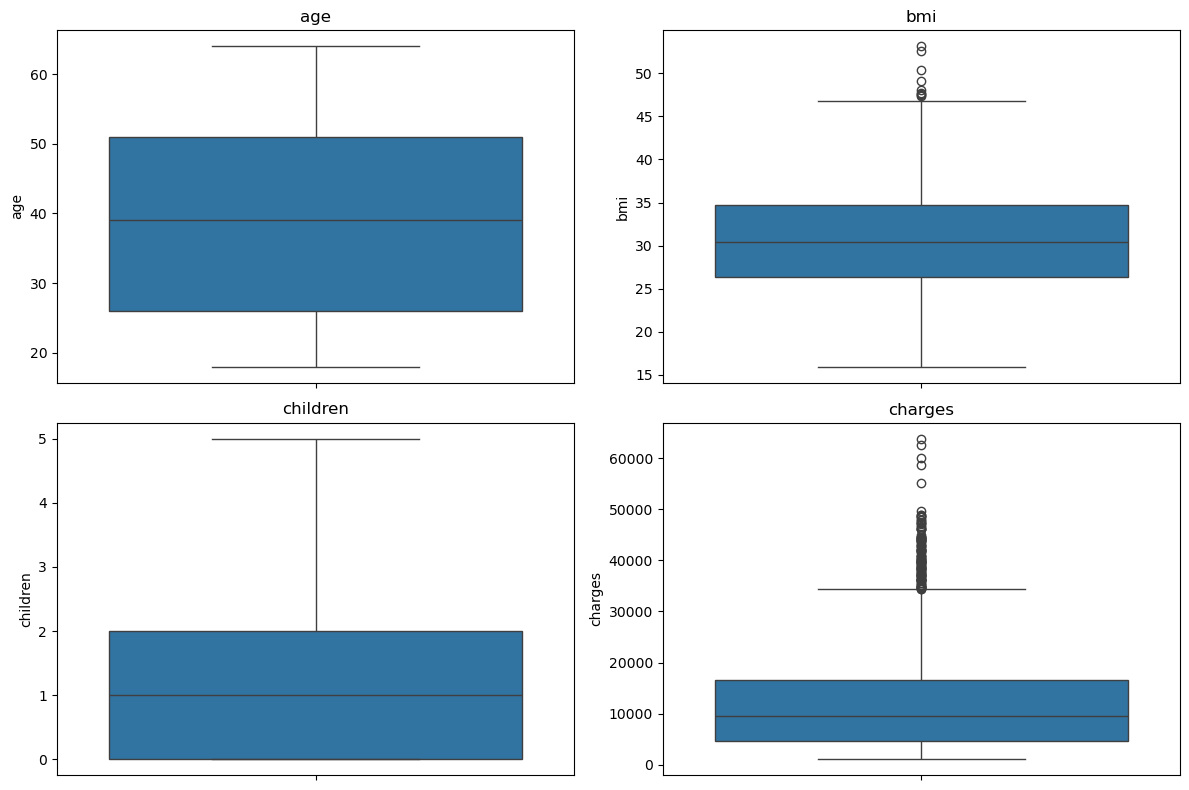

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create subplots
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)   # 2x2 grid (adjust if needed)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [50]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

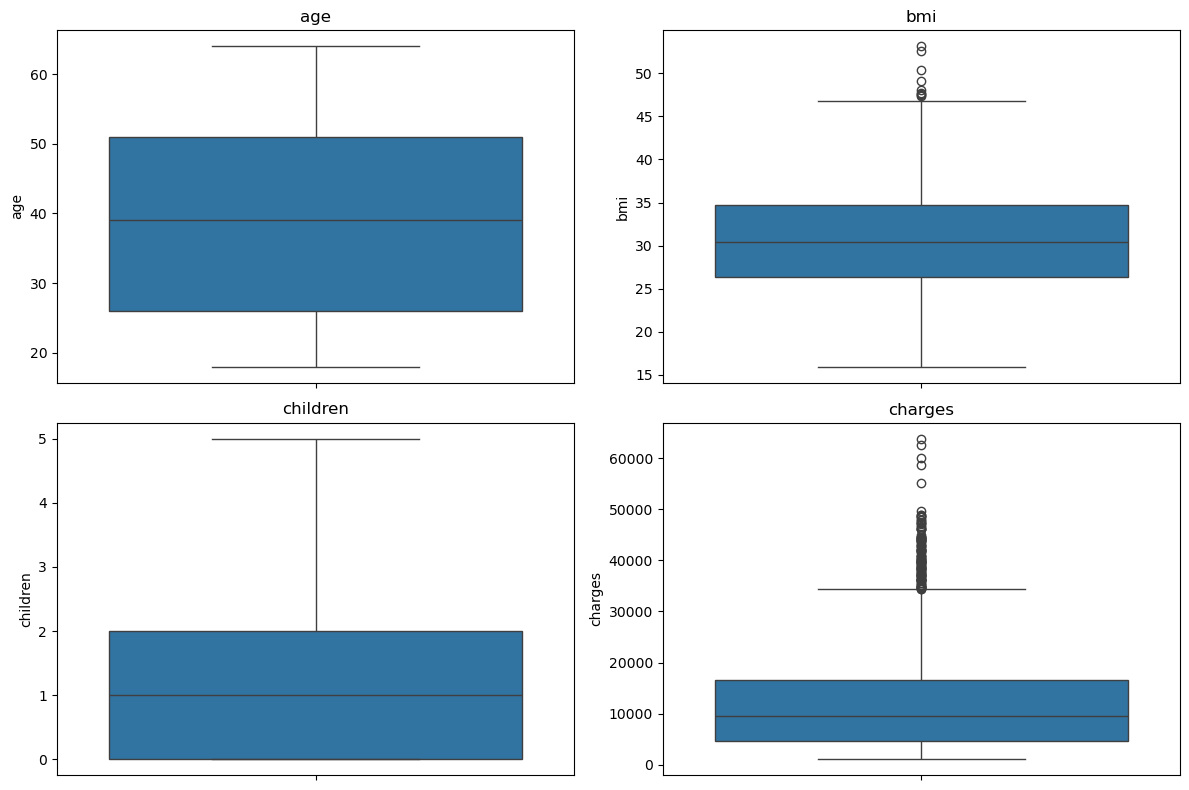

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create subplots
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)   # 2x2 grid (adjust if needed)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Encoding

In [52]:
df = pd.get_dummies(df, drop_first=True) # one hot encoding

In [53]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,37,34.100,4.0,40182.24600,True,True,False,False,True
1,18,34.430,0.0,1137.46970,True,False,False,True,False
2,23,36.670,2.0,38511.62830,False,True,False,False,False
3,32,35.200,2.0,4670.64000,True,False,False,False,True
4,58,32.395,1.0,13019.16105,False,False,False,False,False


In [54]:
df.to_csv("cleaned_data.csv",index=False)